### Immigration Tweets Analysis
- pull dataset stats
- look at llm annotations for dataset

In [32]:
import os
import pandas as pd
import numpy as np

from analysis.utils import *
from src.utils import load_env, set_seed,load_json, get_logger
from src.experiment_config import ExperimentConfig
from src.data_loading import DatasetLoader
from src.db_config import DocAnnotation

from sqlalchemy import create_engine, select, func

import matplotlib.pyplot as plt
import seaborn as sns
set_matplot_style()

In [33]:
# CONNECT TO DATABASE AND LOAD LLM RESULTS
MET_THRESH = 0.3
MEND_MET_THRESH = 0.3

env_vars = load_env()
seed = env_vars["RANDOM_SEED"]
set_seed(seed)

# LOAD CONFIG FOR DATASET OF INTEREST USING ROB RESULTS CONFIG (mendelsohn labelled tweets)
rob_4c_path = "/Users/alexleto/projects/metaphor-detector/results/get_candidate_metaphors/rule_based/tweets_immigration_metaphor_paths_scores.json"
rb_results = load_json(rob_4c_path)

# load experiment config, update paths
config = ExperimentConfig.from_dict(rb_results["config"], logger=get_logger("eval"))
config.repo_dir = env_vars["REPO_PATH"]  # reset repo dir
config.raw_data_dir = env_vars["RAW_DATA_DIR"]  # reset raw data dir
config.db_dir = env_vars["DB_DIR"]  # reset db dir

# get db session for tweet dataset
config.skip_load = True
data_loader = DatasetLoader(config)
tweet_session = data_loader.load_data()

qwen_tweet_llm_res_path = "/Users/alexleto/projects/metaphor-detector/results/llm_ann/llm_metaphor_classifier/tweets_immigration_source_verb_score_qwen.json"
qwen_tweet_llm_df = get_llm_metaphor_class_df(qwen_tweet_llm_res_path)

2026-02-28 18:34:30,192 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...
2026-02-28 18:34:30,192 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...
2026-02-28 18:34:30,192 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...


In [34]:
# LOAD HAND-ANNOTATED MEND TWEETS
mend_df = get_mend_df(config, env_vars["INTERIM_DIR"])
mend_df["id"] = mend_df["id"].astype(str)

2026-02-28 18:34:30,233 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...
2026-02-28 18:34:30,233 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...
2026-02-28 18:34:30,233 - eval - INFO - Found existing database at /Users/alexleto/projects/metaphor-detector/data/dbs/tweets_immigration_hand_labeled.db. Loading data from there...


Loading document annotations from '/Users/alexleto/projects/metaphor-detector/data/interim/tweet_anns.csv'


In [35]:
# mendelson data summary 
source_grouped_df = mend_df.groupby("human_source_domain").agg(count = ("id", "count"))
source_grouped_df

,count
human_source_domain,
animal,200
commodity,199
domain-agnostic,200
parasite,199
pressure,200
vermin,198
war,200
water,200


In [36]:
score_grouped_df = mend_df.groupby("human_metaphor_score").agg(count = ("id", "count"))
# score_grouped_df

In [37]:
print(f"{len(mend_df)} annotated tweets")

1596 annotated tweets


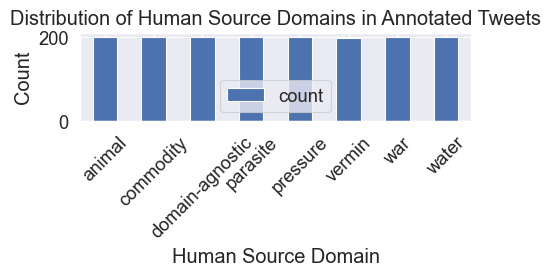

In [38]:
# plot human source domains
mend_df.groupby("human_source_domain").agg(count = ("id", "count")).plot(kind="bar", figsize=(5, 3))
plt.title("Distribution of Human Source Domains in Annotated Tweets")
plt.xlabel("Human Source Domain")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


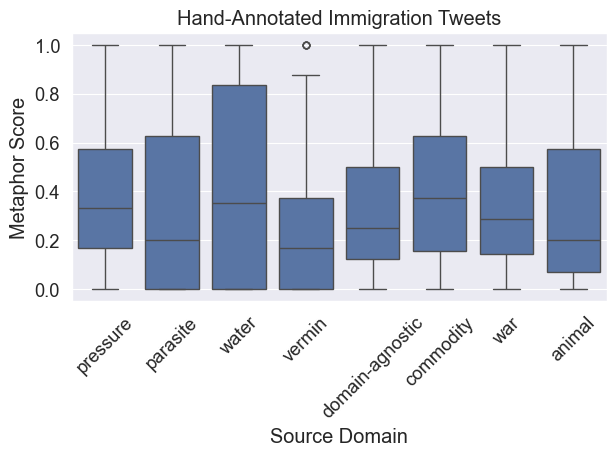

In [39]:
# good plot to show source domains and metaphor score distribution, can also do boxplot to show metaphor score distribution for each source domain
sns.boxplot(data=mend_df, x="human_source_domain", y="human_metaphor_score")
plt.title("Hand-Annotated Immigration Tweets")
plt.xlabel("Source Domain")
plt.ylabel("Metaphor Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/tweets_mend_source_domain_metaphor_scores.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# calculate f1 scores 
qwen_tweet_level_llm_df = qwen_tweet_llm_df.groupby("doc_id").agg(llm_met_score = ("llm_met_score", "mean"))

In [41]:
qwen_eval_df = mend_df.merge(qwen_tweet_level_llm_df, right_on="doc_id", left_on="id", how="left").set_index("id")
qwen_eval_df = qwen_eval_df.fillna(0)
# qwen_eval_df[qwen_eval_df["llm_met_score"].isna()]

In [42]:
qwen_ra_df = rep_mend_analysis(qwen_eval_df, "llm_met_score", "")
qwen_ra_df

,
threshold,
10%,0.572
20%,0.562
30%,0.544
40%,0.538
50%,0.540
60%,0.543
70%,0.547
80%,0.519
90%,0.524


In [44]:
qwen_eval_df["llm_met_class"] = qwen_eval_df["llm_met_score"].apply(lambda x: 1 if x > 0.1 else 0)
qwen_f1_df = mend_f1_table(qwen_eval_df, "llm_met_class", "")
qwen_f1_df

,tn,fp,fn,tp,_p,_r,_f1
threshold,,,,,,,
10%,127,224,303,942,0.808,0.757,0.781
20%,204,431,226,735,0.630,0.765,0.691
30%,253,591,177,575,0.493,0.765,0.600
40%,289,694,141,472,0.405,0.770,0.531
50%,316,781,114,385,0.330,0.772,0.462
60%,344,884,86,282,0.242,0.766,0.368
70%,365,961,65,205,0.176,0.759,0.286
80%,381,1029,49,137,0.117,0.737,0.203
90%,409,1101,21,65,0.056,0.756,0.104
